Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'horse', 'ship', 'truck']

Images per class:
airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
horse: 5000
ship: 5000
truck: 5000


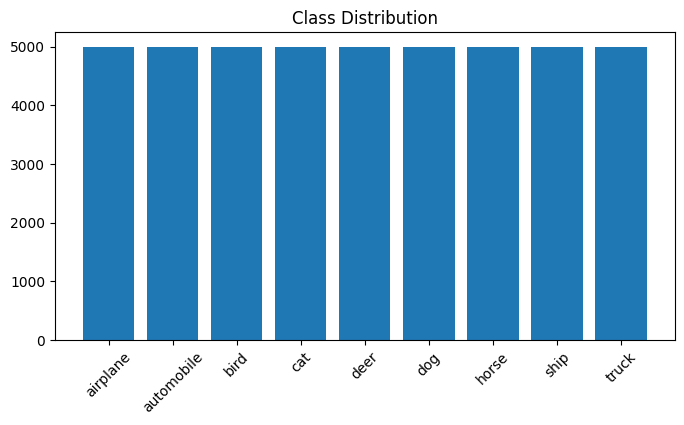


Unique image sizes: {(32, 32)}
Corrupted images: 0


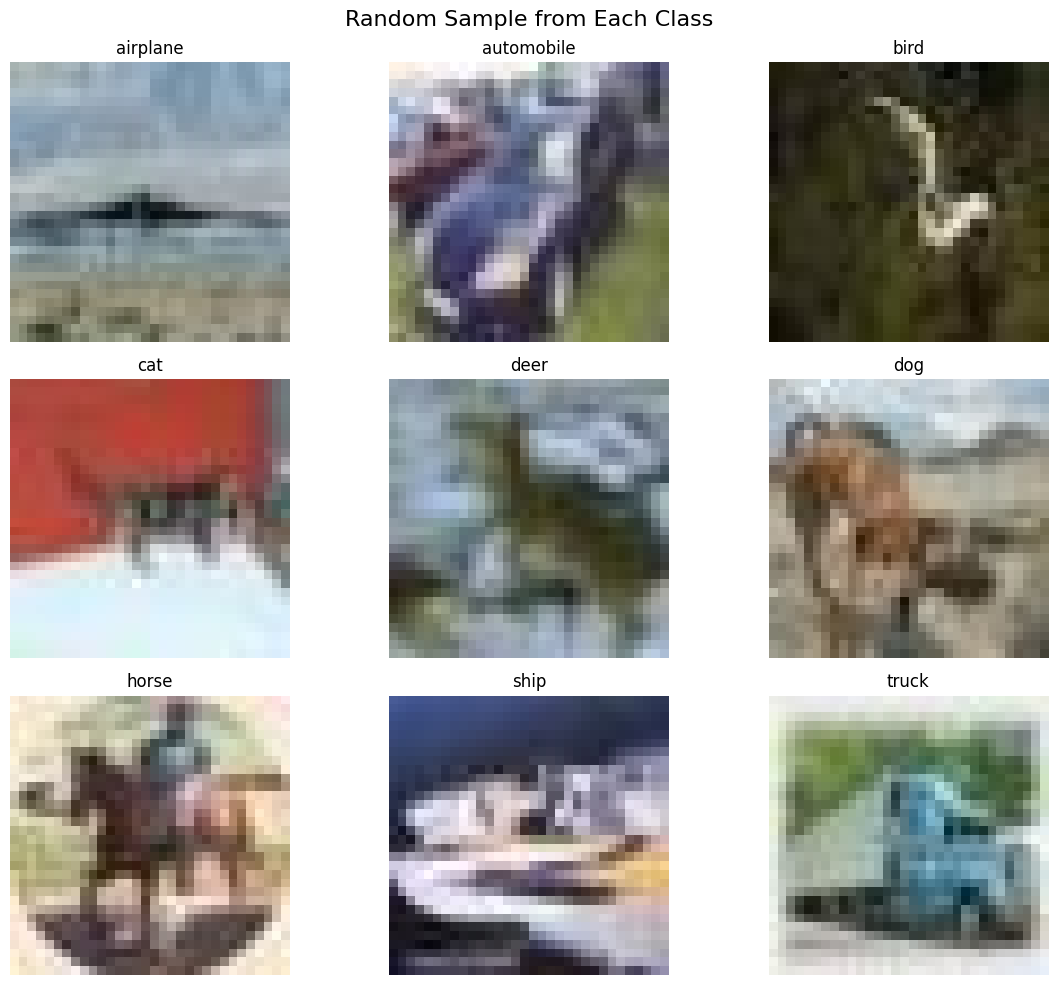

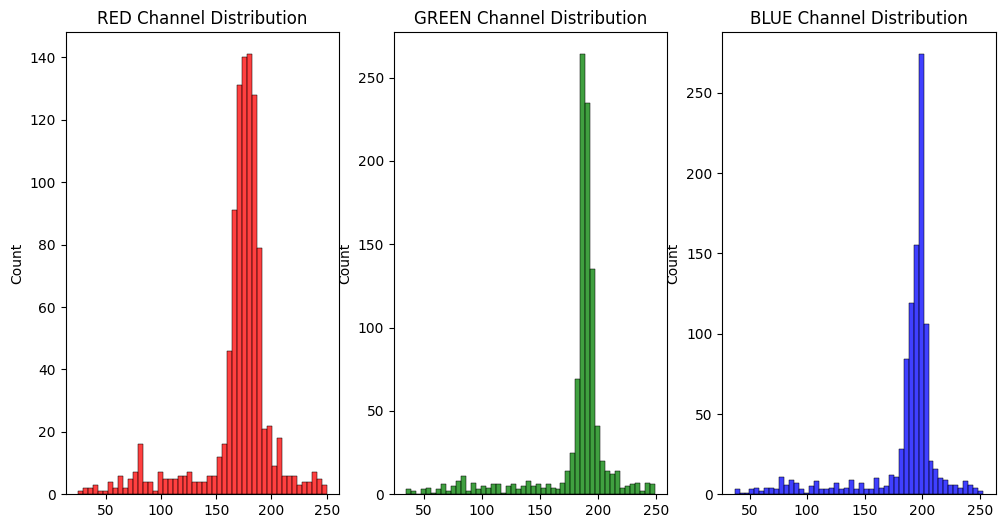


Recommended Normalization:
mean = [0.52461963 0.55828897 0.58782098]
std  = [0.18552486 0.18374406 0.19512308]


In [11]:
import os
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_DIR = "train/"

# ----------------------------------------------------
# 1. List classes and count images per class
# ----------------------------------------------------
classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
print("Classes:", classes)

class_counts = {}
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[cls] = len(images)

print("\nImages per class:")
for k, v in class_counts.items():
    print(f"{k}: {v}")

plt.figure(figsize=(8,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

# ----------------------------------------------------
# 2. Check image sizes and detect corrupted images
# ----------------------------------------------------
sizes = []
broken = 0

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(os.path.join(cls_path, img_name))
                sizes.append(img.size)
            except Exception as e:
                broken += 1

print("\nUnique image sizes:", set(sizes))
print("Corrupted images:", broken)

# ----------------------------------------------------
# 3. Show random samples from each class
# ----------------------------------------------------
plt.figure(figsize=(12, 10))
index = 1

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    sample = random.choice(imgs)

    img = Image.open(os.path.join(cls_path, sample))
    plt.subplot(3, 3, index)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    index += 1

plt.suptitle("Random Sample from Each Class", fontsize=16)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# 4. Plot RGB histogram of a sample image
# ----------------------------------------------------
sample_img_path = os.path.join(TRAIN_DIR, classes[0], os.listdir(os.path.join(TRAIN_DIR, classes[0]))[0])
img = np.array(Image.open(sample_img_path).convert("RGB"))

plt.figure(figsize=(12,6))
colors = ["red", "green", "blue"]

for i in range(3):
    plt.subplot(1,3,i+1)
    sns.histplot(img[:,:,i].flatten(), bins=50, color=colors[i])
    plt.title(f"{colors[i].upper()} Channel Distribution")

plt.show()

# ----------------------------------------------------
# 5. Compute mean and std for recommended normalization
# ----------------------------------------------------
means = []
stds = []
count = 0
max_samples = 2000   # Limit to speed up calculations

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img = np.array(Image.open(os.path.join(cls_path, img_name)).convert("RGB")) / 255.0
            means.append(img.mean(axis=(0,1)))
            stds.append(img.std(axis=(0,1)))
            count += 1
            if count >= max_samples:
                break
    if count >= max_samples:
        break

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print("\nRecommended Normalization:")
print("mean =", mean)
print("std  =", std)
